In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("fashion_trend.csv")
df.head()

,record_id,date,year,season,region,product_id,category,product_name,color,fabric,...,influencer_mentions,customer_rating,return_rate_pct,stock_availability_pct,repeat_purchase_rate_pct,website_click_through_rate,days_in_top_100,trending_score,is_trending,trending_label
0,1,2023-08-09,2023,Summer,Asia Pacific,P100000,Dresses,Bodycon Dress,Burgundy,Wool,...,14,3.6,14.2,92.6,18.2,2.48,38,61.05,1,Trending
1,2,2024-05-26,2024,Winter,North America,P100001,Dresses,Bodycon Dress,Cream,Denim,...,15,4.5,15.9,85.9,22.3,3.68,23,59.19,0,Not Trending
2,3,2025-05-04,2025,Spring,Middle East,P100002,Accessories,Mini Bag,Charcoal,Cotton,...,18,4.5,15.5,90.9,15.4,4.79,17,40.65,0,Not Trending
3,4,2023-11-05,2023,Winter,North America,P100003,Accessories,Mini Bag,Sage Green,Wool,...,18,4.1,9.2,84.6,26.7,3.35,13,45.82,0,Not Trending
4,5,2024-02-06,2024,Spring,Europe,P100004,Footwear,Ballet Flats,Cherry Red,Cotton,...,14,4.2,14.6,63.1,20.7,2.71,23,37.85,0,Not Trending


In [3]:
df.shape

(10000, 28)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   10000 non-null  int64  
 1   date                        10000 non-null  str    
 2   year                        10000 non-null  int64  
 3   season                      10000 non-null  str    
 4   region                      10000 non-null  str    
 5   product_id                  10000 non-null  str    
 6   category                    10000 non-null  str    
 7   product_name                10000 non-null  str    
 8   color                       10000 non-null  str    
 9   fabric                      10000 non-null  str    
 10  price_tier                  10000 non-null  str    
 11  price_usd                   10000 non-null  float64
 12  discount_pct                10000 non-null  float64
 13  historical_sales_units      10000 non-null 

In [5]:
df.isnull().sum()

record_id                     0
date                          0
year                          0
season                        0
region                        0
product_id                    0
category                      0
product_name                  0
color                         0
fabric                        0
price_tier                    0
price_usd                     0
discount_pct                  0
historical_sales_units        0
search_volume_index           0
social_media_mentions         0
instagram_hashtag_count       0
tiktok_video_count            0
influencer_mentions           0
customer_rating               0
return_rate_pct               0
stock_availability_pct        0
repeat_purchase_rate_pct      0
website_click_through_rate    0
days_in_top_100               0
trending_score                0
is_trending                   0
trending_label                0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

### Cleaning

In [7]:
# Removing duplicates
df = df.drop_duplicates()

# Fill numeric NaNs with column mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical NaNs with column mode (assign back - inplace=True on a
# column slice silently no-ops under pandas Copy-on-Write)
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()  # 0

np.int64(0)

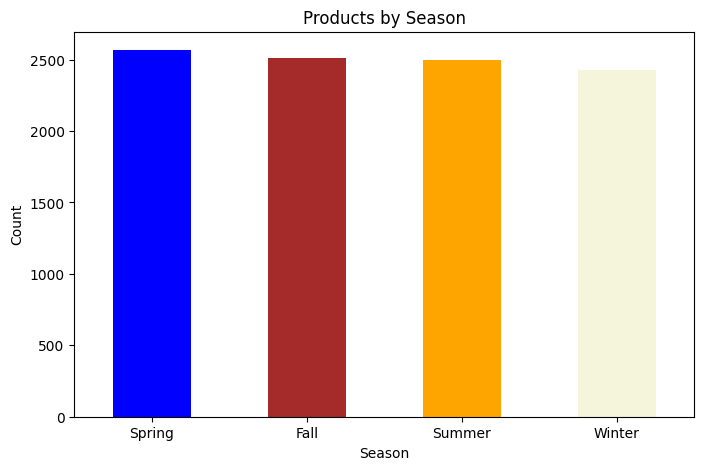

In [8]:
df["season"].value_counts().plot(
    kind="bar",
    figsize=(8, 5),
    color=['blue', 'brown', 'orange', 'beige']
)
plt.title("Products by Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

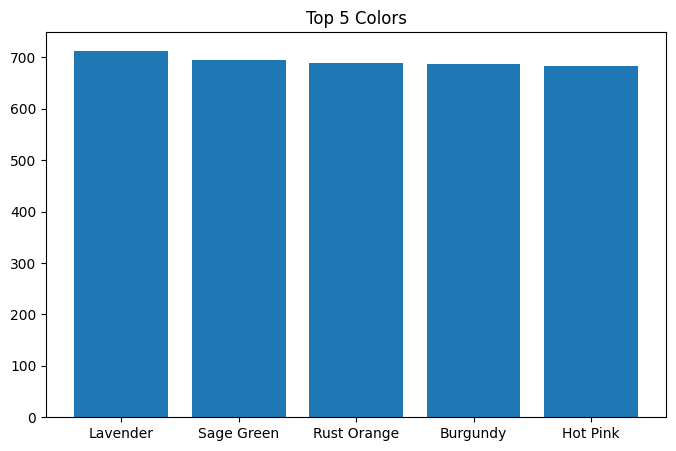

In [9]:
top = df["color"].value_counts().head(5)
plt.figure(figsize=(8, 5))
plt.bar(top.index, top.values)
plt.title("Top 5 Colors")
plt.xticks(rotation=0)
plt.show()

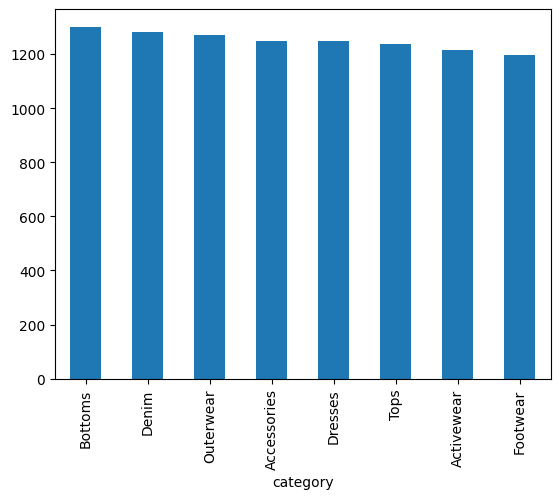

In [10]:
df["category"].value_counts().head(10).plot(kind="bar")
plt.show()

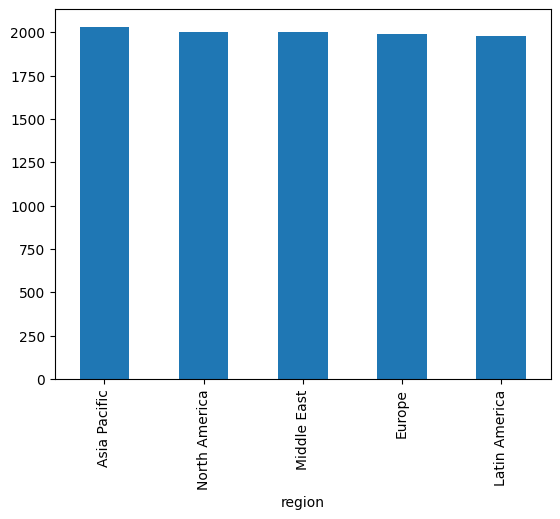

In [11]:
df["region"].value_counts().plot(kind="bar")
plt.show()

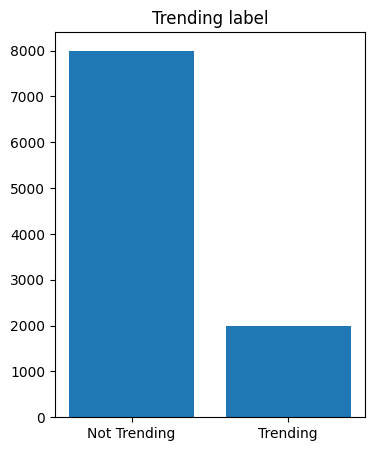

In [12]:
top = df["trending_label"].value_counts()
plt.figure(figsize=(4, 5))
plt.bar(top.index, top.values)
plt.title("Trending label")
plt.xticks(rotation=0)
plt.show()

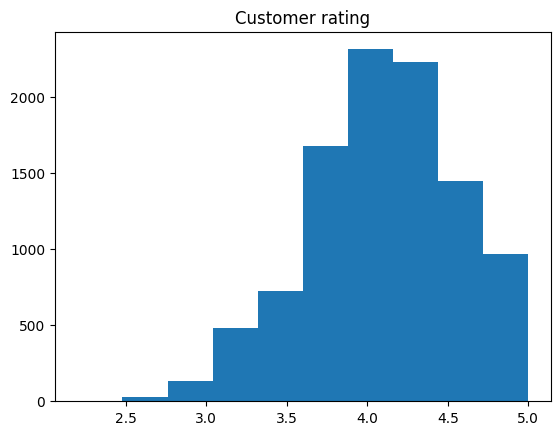

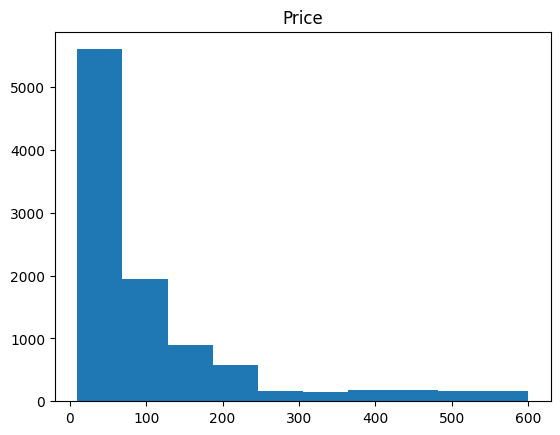

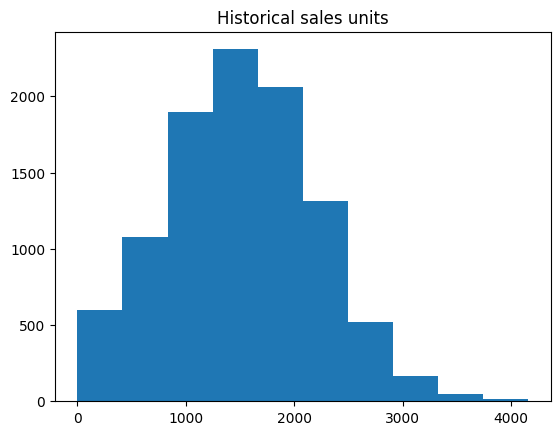

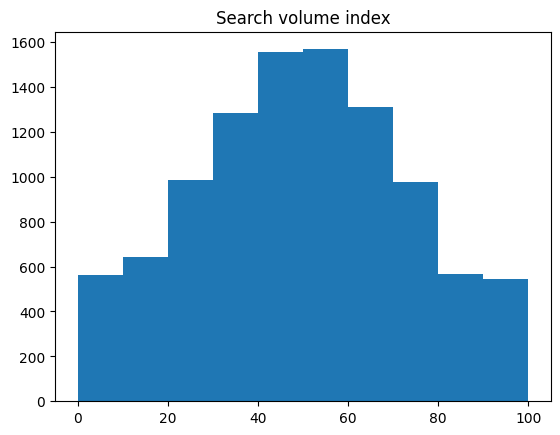

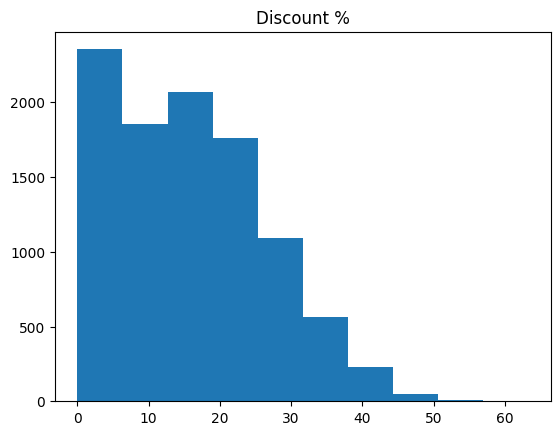

In [13]:
plt.hist(df["customer_rating"]); plt.title("Customer rating"); plt.show()
plt.hist(df["price_usd"]); plt.title("Price"); plt.show()
plt.hist(df["historical_sales_units"]); plt.title("Historical sales units"); plt.show()
plt.hist(df["search_volume_index"]); plt.title("Search volume index"); plt.show()
plt.hist(df["discount_pct"]); plt.title("Discount %"); plt.show()

### Feature engineering

In [14]:
def price_tier(price):
    if price < 30:
        return "Budget"
    elif price < 70:
        return "Mid"
    else:
        return "Premium"

df["price_tier"] = df["price_usd"].apply(price_tier)

In [15]:
df["popularity_score"] = (
    df["historical_sales_units"] * 0.4
    + df["search_volume_index"] * 0.3
    + df["social_media_mentions"] * 0.2
    + df["customer_rating"] * 10 * 0.1
)

df["social_buzz"] = (
    df["instagram_hashtag_count"]
    + df["tiktok_video_count"]
    + df["influencer_mentions"]
)

df["engagement"] = (
    df["website_click_through_rate"] * df["repeat_purchase_rate_pct"]
)

In [16]:
features = [
    "season", "region", "category", "color", "fabric", "price_tier",
    "price_usd", "discount_pct", "historical_sales_units", "search_volume_index",
    "social_media_mentions", "instagram_hashtag_count", "tiktok_video_count",
    "influencer_mentions", "customer_rating", "return_rate_pct",
    "stock_availability_pct", "repeat_purchase_rate_pct",
    "website_click_through_rate", "popularity_score", "social_buzz", "engagement"
]

target = "trending_label"

categorical_cols = ["season", "region", "category", "color", "fabric", "price_tier"]

encoders = {}
for col in categorical_cols:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col].astype(str))
    encoders[col] = enc

In [17]:
X = df[features].copy()
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [19]:
prediction = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, prediction))

Accuracy: 0.836


In [20]:
print(confusion_matrix(y_test, prediction))

[[1558   42]
 [ 286  114]]


In [21]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

Not Trending       0.84      0.97      0.90      1600
    Trending       0.73      0.28      0.41       400

    accuracy                           0.84      2000
   macro avg       0.79      0.63      0.66      2000
weighted avg       0.82      0.84      0.81      2000



In [22]:
import joblib

joblib.dump(model, "fashion_trend_model.pkl")
joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [23]:
print(df.columns.tolist())

['record_id', 'date', 'year', 'season', 'region', 'product_id', 'category', 'product_name', 'color', 'fabric', 'price_tier', 'price_usd', 'discount_pct', 'historical_sales_units', 'search_volume_index', 'social_media_mentions', 'instagram_hashtag_count', 'tiktok_video_count', 'influencer_mentions', 'customer_rating', 'return_rate_pct', 'stock_availability_pct', 'repeat_purchase_rate_pct', 'website_click_through_rate', 'days_in_top_100', 'trending_score', 'is_trending', 'trending_label', 'popularity_score', 'social_buzz', 'engagement']
